IMPORT

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
TABLES_DIR = BASE_DIR / "outputs" / "tables"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

RFM_CLUSTERED_PATH = PROCESSED_DIR / "rfm_clustered.csv"
BEHAVIOUR_CLUSTERED_PATH = PROCESSED_DIR / "rfm_refined_behavioural_clustered.csv"
EVALUATION_PATH = TABLES_DIR / "final_clustering_evaluation_metrics.csv"
RANKING_PATH = TABLES_DIR / "final_model_ranking.csv"
PROFILE_PATH = TABLES_DIR / "refined_behavioural_cluster_profile.csv"

print("Setup complete.")

Setup complete.


LOAD FINAL OUTPUT

In [2]:
rfm = pd.read_csv(RFM_CLUSTERED_PATH)
behaviour = pd.read_csv(BEHAVIOUR_CLUSTERED_PATH)
evaluation_df = pd.read_csv(EVALUATION_PATH)
ranking_df = pd.read_csv(RANKING_PATH)
cluster_profile = pd.read_csv(PROFILE_PATH)

print("RFM:", rfm.shape)
print("Refined behavioural:", behaviour.shape)
print("Evaluation table:", evaluation_df.shape)
print("Ranking table:", ranking_df.shape)
print("Cluster profile:", cluster_profile.shape)

display(evaluation_df)
display(cluster_profile)

RFM: (4338, 7)
Refined behavioural: (4338, 12)
Evaluation table: (6, 5)
Ranking table: (6, 9)
Cluster profile: (4, 9)


,Dataset,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,Traditional RFM,K-Means,0.3850,0.9094,4943.08
1,Traditional RFM,Hierarchical,0.3230,0.9026,3748.42
2,Traditional RFM,GMM,0.1842,1.5741,1919.84
3,Refined Behavioural,K-Means,0.4367,0.9358,3793.53
4,Refined Behavioural,Hierarchical,0.4049,1.0768,3391.38
5,Refined Behavioural,GMM,0.3018,2.1251,2343.00


,KMeans_Cluster,Recency,Frequency,Monetary,Customer_Lifetime_Days,Purchase_Velocity,Purchase_Interval_Std,Purchase_Regularity_Index,Invoice_Value_CV
0,0,62.80,1.05,425.47,1.02,1.04,0.00,1.00,0.03
1,1,41.26,7.78,3824.56,241.08,0.04,42.66,0.04,0.52
2,2,77.31,2.07,972.93,124.44,0.08,0.30,0.96,0.39
3,3,272.99,1.19,438.72,5.08,0.97,0.16,0.99,0.06


FINAL EVALUATION TABLE FOR REPORT

In [3]:
report_eval = evaluation_df.copy()

report_eval = report_eval.sort_values(
    by=["Dataset", "Silhouette Score"],
    ascending=[True, False]
)

display(report_eval)

report_eval.to_csv(
    TABLES_DIR / "report_final_evaluation_table.csv",
    index=False
)

print("Saved report_final_evaluation_table.csv")

,Dataset,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
3,Refined Behavioural,K-Means,0.4367,0.9358,3793.53
4,Refined Behavioural,Hierarchical,0.4049,1.0768,3391.38
5,Refined Behavioural,GMM,0.3018,2.1251,2343.00
0,Traditional RFM,K-Means,0.3850,0.9094,4943.08
1,Traditional RFM,Hierarchical,0.3230,0.9026,3748.42
2,Traditional RFM,GMM,0.1842,1.5741,1919.84


Saved report_final_evaluation_table.csv


SILHOUETTE COMPARISON BAR CHART

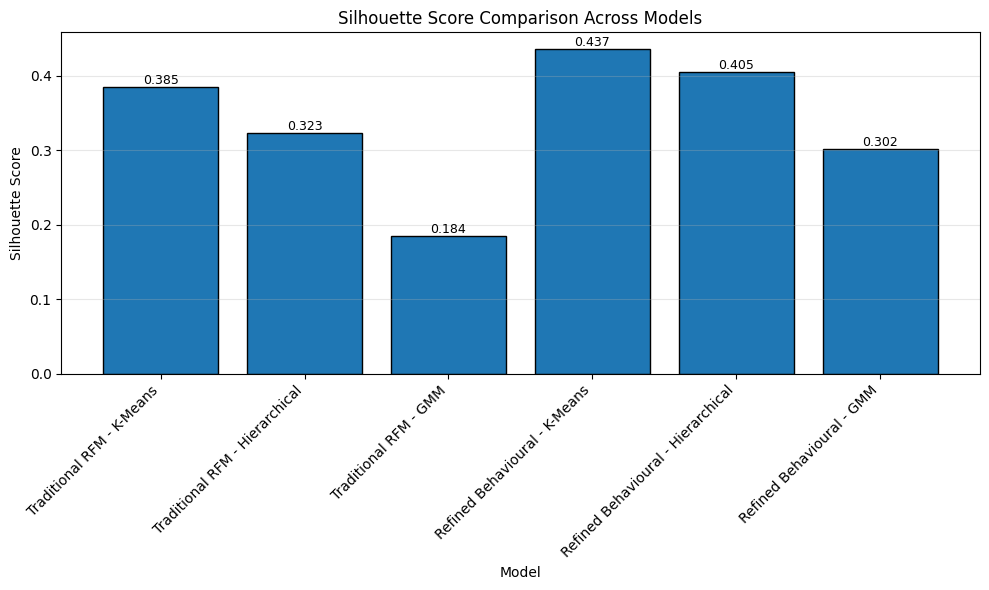

In [4]:
plt.figure(figsize=(10, 6))

labels = evaluation_df["Dataset"] + " - " + evaluation_df["Model"]

bars = plt.bar(
    labels,
    evaluation_df["Silhouette Score"],
    edgecolor="black"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Silhouette Score Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "report_silhouette_comparison_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

DAVIES BOULDIN COMPARISON BAR CHART 

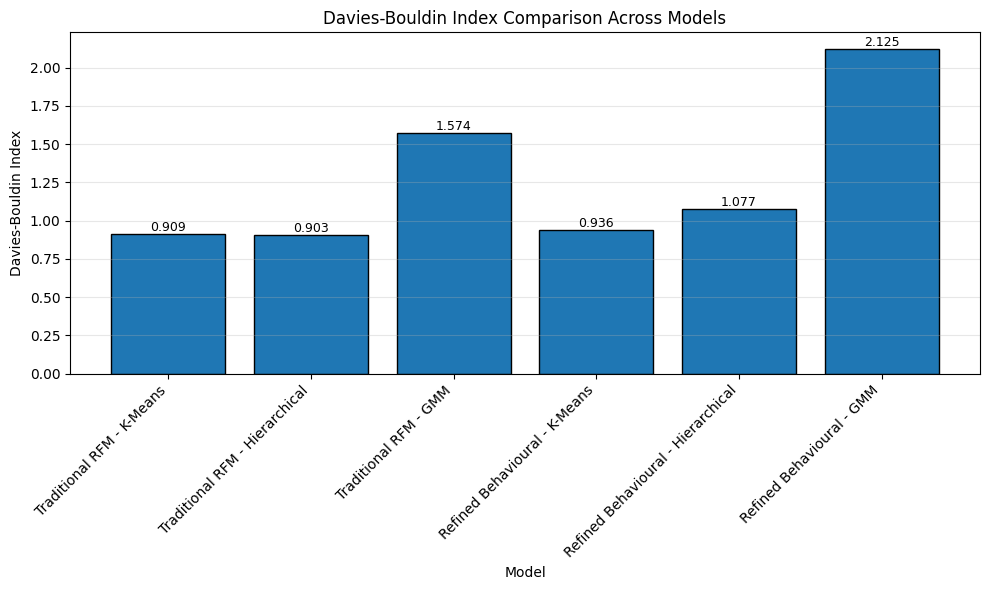

In [5]:
plt.figure(figsize=(10, 6))

labels = evaluation_df["Dataset"] + " - " + evaluation_df["Model"]

bars = plt.bar(
    labels,
    evaluation_df["Davies-Bouldin Index"],
    edgecolor="black"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Davies-Bouldin Index Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Davies-Bouldin Index")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "report_davies_bouldin_comparison_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

CALINSKI HARABASZ COMPARISON BAR CHART 

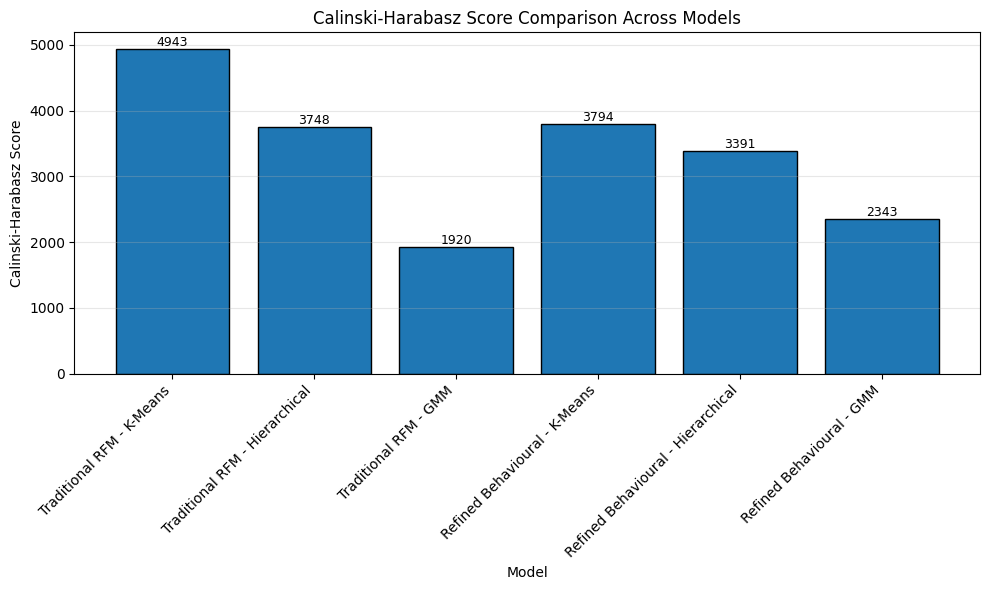

In [6]:
plt.figure(figsize=(10, 6))

labels = evaluation_df["Dataset"] + " - " + evaluation_df["Model"]

bars = plt.bar(
    labels,
    evaluation_df["Calinski-Harabasz Score"],
    edgecolor="black"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Calinski-Harabasz Score Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Calinski-Harabasz Score")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "report_calinski_harabasz_comparison_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

K MEANS FOCUSED COMPARISON

In [7]:
kmeans_comparison = evaluation_df[
    evaluation_df["Model"] == "K-Means"
].copy()

display(kmeans_comparison)

kmeans_comparison.to_csv(
    TABLES_DIR / "report_kmeans_rfm_vs_behavioural.csv",
    index=False
)

,Dataset,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,Traditional RFM,K-Means,0.3850,0.9094,4943.08
3,Refined Behavioural,K-Means,0.4367,0.9358,3793.53


K MEANS RFM VS REFINED BEHAVIOURAL CHART 

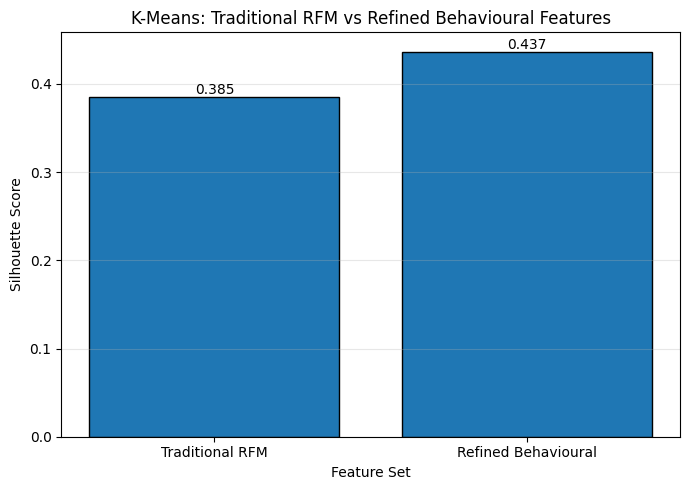

In [8]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    kmeans_comparison["Dataset"],
    kmeans_comparison["Silhouette Score"],
    edgecolor="black"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("K-Means: Traditional RFM vs Refined Behavioural Features")
plt.xlabel("Feature Set")
plt.ylabel("Silhouette Score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "report_kmeans_rfm_vs_refined_behavioural.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

CLUSTER DISTRIBUTION

In [9]:
cluster_counts = (
    behaviour["KMeans_Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_counts.columns = ["Cluster", "Customer_Count"]

display(cluster_counts)

cluster_counts.to_csv(
    TABLES_DIR / "report_refined_behavioural_cluster_counts.csv",
    index=False
)

,Cluster,Customer_Count
0,0,856
1,1,1943
2,2,780
3,3,759


CLUSTER DISTRIBUTION CHART 

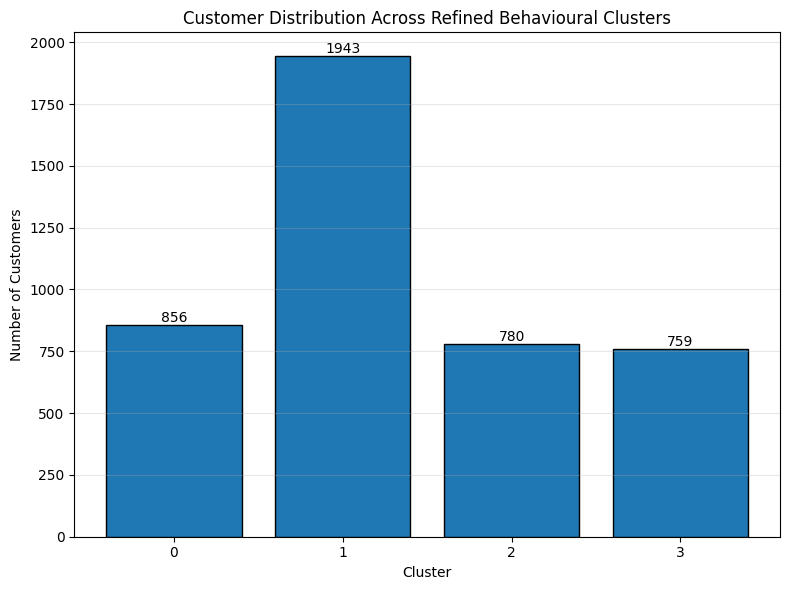

In [10]:
plt.figure(figsize=(8, 6))

bars = plt.bar(
    cluster_counts["Cluster"].astype(str),
    cluster_counts["Customer_Count"],
    edgecolor="black"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.title("Customer Distribution Across Refined Behavioural Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "report_refined_behavioural_cluster_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

CLEAN CLSUTER PROFILE TABLE 

In [17]:
cluster_profile_clean = cluster_profile.copy()

if "KMeans_Cluster" not in cluster_profile_clean.columns:
    cluster_profile_clean = cluster_profile_clean.rename(
        columns={cluster_profile_clean.columns[0]: "KMeans_Cluster"}
    )

display(cluster_profile_clean)

cluster_profile_clean.to_csv(
    TABLES_DIR / "report_refined_behavioural_cluster_profile.csv",
    index=False
)

,KMeans_Cluster,Recency,Frequency,Monetary,Customer_Lifetime_Days,Purchase_Velocity,Purchase_Interval_Std,Purchase_Regularity_Index,Invoice_Value_CV
0,0,62.80,1.05,425.47,1.02,1.04,0.00,1.00,0.03
1,1,41.26,7.78,3824.56,241.08,0.04,42.66,0.04,0.52
2,2,77.31,2.07,972.93,124.44,0.08,0.30,0.96,0.39
3,3,272.99,1.19,438.72,5.08,0.97,0.16,0.99,0.06


HEATMAP 

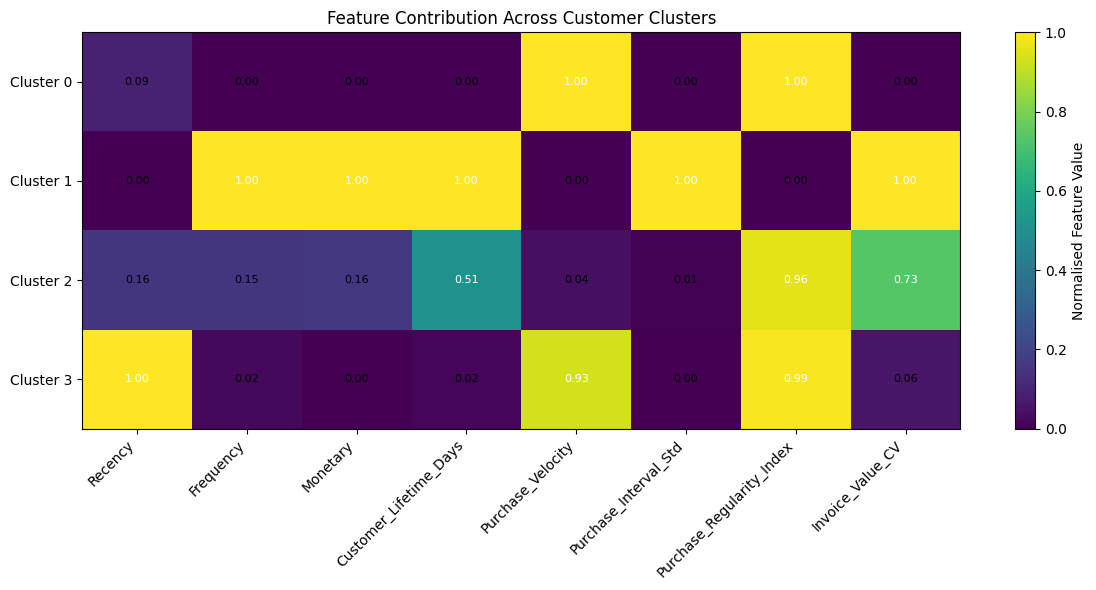

In [18]:
# ==========================================================
# FEATURE CONTRIBUTION HEATMAP
# ==========================================================

import matplotlib.pyplot as plt

# Copy cluster profile
heatmap_df = cluster_profile_clean.copy()

# Remove cluster column for plotting
heatmap_df = heatmap_df.set_index("KMeans_Cluster")

# Normalise each feature (0–1) for comparison
heatmap_norm = (heatmap_df - heatmap_df.min()) / (
    heatmap_df.max() - heatmap_df.min()
)

plt.figure(figsize=(12,6))

plt.imshow(
    heatmap_norm,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Normalised Feature Value")

plt.xticks(
    range(len(heatmap_norm.columns)),
    heatmap_norm.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(heatmap_norm.index)),
    [f"Cluster {i}" for i in heatmap_norm.index]
)

plt.title("Feature Contribution Across Customer Clusters")

# Write values inside cells
for i in range(heatmap_norm.shape[0]):
    for j in range(heatmap_norm.shape[1]):
        plt.text(
            j,
            i,
            f"{heatmap_norm.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if heatmap_norm.iloc[i,j] > 0.5 else "black"
        )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "feature_contribution_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

FEATURE IMPORTANCE RANKING 

In [19]:
# ==========================================================
# FEATURE IMPORTANCE RANKING ACROSS CLUSTERS
# ==========================================================

# Copy cluster profile
importance_df = cluster_profile_clean.copy()

# Set cluster as index
importance_df = importance_df.set_index("KMeans_Cluster")

# Remove persona label if it exists
importance_df = importance_df.drop(columns=["Persona_Label"], errors="ignore")

# Calculate how much each feature varies across clusters
feature_importance = pd.DataFrame({
    "Feature": importance_df.columns,
    "Between_Cluster_Range": importance_df.max() - importance_df.min(),
    "Between_Cluster_Std": importance_df.std()
})

# Sort by standard deviation across clusters
feature_importance = feature_importance.sort_values(
    by="Between_Cluster_Std",
    ascending=False
).reset_index(drop=True)

display(feature_importance)

# Save table
feature_importance.to_csv(
    TABLES_DIR / "report_feature_importance_ranking.csv",
    index=False
)

print("Feature importance ranking saved.")

,Feature,Between_Cluster_Range,Between_Cluster_Std
0,Monetary,3399.09,1626.212044
1,Customer_Lifetime_Days,240.06,114.172925
2,Recency,231.73,107.293758
3,Purchase_Interval_Std,42.66,21.253687
4,Frequency,6.73,3.203637
5,Purchase_Velocity,1.00,0.546588
6,Purchase_Regularity_Index,0.96,0.471973
7,Invoice_Value_CV,0.49,0.242899


Feature importance ranking saved.


FEATURE IMPORTANCE BAR CHART 

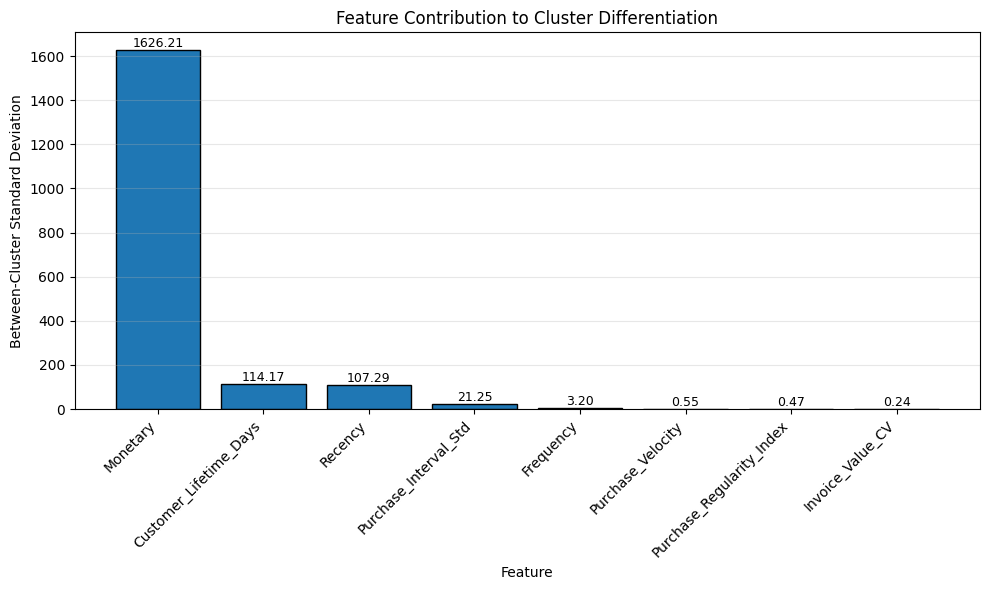

: 

In [ ]:
# ==========================================================
# FEATURE IMPORTANCE BAR CHART
# ==========================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    feature_importance["Feature"],
    feature_importance["Between_Cluster_Std"],
    edgecolor="black"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Feature Contribution to Cluster Differentiation")
plt.xlabel("Feature")
plt.ylabel("Between-Cluster Standard Deviation")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "report_feature_importance_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

PERSONA LABELS 

In [15]:
persona_map = {
    0: "New / One-Time Customers",
    1: "High-Value Loyal Customers",
    2: "Growing / Potential Loyal Customers",
    3: "At-Risk / Dormant Customers"
}

cluster_profile_clean["Persona_Label"] = cluster_profile_clean["KMeans_Cluster"].map(persona_map)

display(cluster_profile_clean)

cluster_profile_clean.to_csv(
    TABLES_DIR / "report_cluster_personas.csv",
    index=False
)

,KMeans_Cluster,Recency,Frequency,Monetary,Customer_Lifetime_Days,Purchase_Velocity,Purchase_Interval_Std,Purchase_Regularity_Index,Invoice_Value_CV,Persona_Label
0,0,62.80,1.05,425.47,1.02,1.04,0.00,1.00,0.03,New / One-Time Customers
1,1,41.26,7.78,3824.56,241.08,0.04,42.66,0.04,0.52,High-Value Loyal Customers
2,2,77.31,2.07,972.93,124.44,0.08,0.30,0.96,0.39,Growing / Potential Loyal Customers
3,3,272.99,1.19,438.72,5.08,0.97,0.16,0.99,0.06,At-Risk / Dormant Customers


RESEARCH RESULT SUMMARY 

In [13]:
rfm_kmeans = evaluation_df[
    (evaluation_df["Dataset"] == "Traditional RFM") &
    (evaluation_df["Model"] == "K-Means")
].iloc[0]

behaviour_kmeans = evaluation_df[
    (evaluation_df["Dataset"] == "Refined Behavioural") &
    (evaluation_df["Model"] == "K-Means")
].iloc[0]

silhouette_improvement = (
    (behaviour_kmeans["Silhouette Score"] - rfm_kmeans["Silhouette Score"])
    / rfm_kmeans["Silhouette Score"]
) * 100

summary_text = f"""
FINAL VISUALISATION SUMMARY

Traditional RFM K-Means Silhouette Score: {rfm_kmeans['Silhouette Score']}
Refined Behavioural K-Means Silhouette Score: {behaviour_kmeans['Silhouette Score']}

Silhouette improvement: {silhouette_improvement:.2f}%

The refined behavioural volatility feature set achieved stronger cluster separation
than the traditional RFM baseline under K-Means. This supports the research objective
that carefully selected behavioural volatility features can improve customer
segmentation quality while also providing richer behavioural interpretability.
"""

print(summary_text)

with open(TABLES_DIR / "report_visualisation_summary.txt", "w") as f:
    f.write(summary_text)


FINAL VISUALISATION SUMMARY

Traditional RFM K-Means Silhouette Score: 0.385
Refined Behavioural K-Means Silhouette Score: 0.4367

Silhouette improvement: 13.43%

The refined behavioural volatility feature set achieved stronger cluster separation
than the traditional RFM baseline under K-Means. This supports the research objective
that carefully selected behavioural volatility features can improve customer
segmentation quality while also providing richer behavioural interpretability.



FINAL OUTPUT CHECK LIST 

In [14]:
print("="*80)
print("09_visualizations.ipynb COMPLETED SUCCESSFULLY")
print("="*80)

print("Report-ready tables saved:")
print("✓ report_final_evaluation_table.csv")
print("✓ report_kmeans_rfm_vs_behavioural.csv")
print("✓ report_refined_behavioural_cluster_counts.csv")
print("✓ report_refined_behavioural_cluster_profile.csv")
print("✓ report_cluster_personas.csv")
print("✓ report_visualisation_summary.txt")

print("\nReport-ready figures saved:")
print("✓ report_silhouette_comparison_bar.png")
print("✓ report_davies_bouldin_comparison_bar.png")
print("✓ report_calinski_harabasz_comparison_bar.png")
print("✓ report_kmeans_rfm_vs_refined_behavioural.png")
print("✓ report_refined_behavioural_cluster_distribution.png")
print("✓ report_normalised_cluster_profile.png")

print("="*80)

09_visualizations.ipynb COMPLETED SUCCESSFULLY
Report-ready tables saved:
✓ report_final_evaluation_table.csv
✓ report_kmeans_rfm_vs_behavioural.csv
✓ report_refined_behavioural_cluster_counts.csv
✓ report_refined_behavioural_cluster_profile.csv
✓ report_cluster_personas.csv
✓ report_visualisation_summary.txt

Report-ready figures saved:
✓ report_silhouette_comparison_bar.png
✓ report_davies_bouldin_comparison_bar.png
✓ report_calinski_harabasz_comparison_bar.png
✓ report_kmeans_rfm_vs_refined_behavioural.png
✓ report_refined_behavioural_cluster_distribution.png
✓ report_normalised_cluster_profile.png
